# Runs all QM7 experiments with the full dataset!

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

Apparently 0.015 is what multitask will get, and 0.0143 is the best (MPNN)

In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

from notebook.services.config import ConfigManager
ConfigManager().update('notebook', {'ExecuteTime': {
   	'display_absolute_timestamps': False,
    'relative_timing_update_period': 5,
    'template': {
    	'executed': 'started ${start_time}, finished in ${duration}',
    }
}})

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM7"
test_file='qm7.csv'
data_file_name='qm7_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

num_repeats=20
num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

TensorFlow version: 2.5.0
DeepChem version: 2.5.0


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

In [3]:
hdf5_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	6838
num_of_molecules is:	 128
MolID: count
Counter({127: 6711, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [4]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'u0_atom_norm', 'wasser_1', 'wasser_2', 'wasser_3']>

In [5]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [6]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['u0_atom']

## Functions

In [7]:
metric_labels

['mean_squared_error', 'pearson_r2_score', 'mae_score', 'rmse']

In [8]:
def load_all_hdf5(fh,
                  num_of_rows, 
                  column_headers):
    """If dataset is small enough, load it all into memory
    fh = file handle
    num_of_rows = number of rows of data (i.e. molecules)
    column_headers into the hdf5 file"""
    data = np.zeros((num_of_rows,len(column_headers)))
    for key_num in range(len(column_headers)):
        key = column_headers[key_num]
        #print(key_num)
        d=fh[key]
        data[:,key_num] = d
    return data

def do_transform(transformers, dataset):
    for transformer in transformers:
        dataset = transformer.transform(dataset)
    return dataset

################## not copied into helper yet ####################

def get_them_metrics(
    model,
    datasets,
    metrics,
    metric_labels,
    transformers=[],
):
    """gross function meh gets data tho"""
    ugh=[]
    for dataset in datasets:
        if transformers == []:
            egg=model.evaluate(
                dataset, 
                metrics)
        else:
            egg=model.evaluate(
                dataset, 
                metrics,
                transformers = transformers)
        for metric_label in metric_labels:
            if metric_label == 'rmse':
                ugh.append(np.sqrt(egg['mean_squared_error']))
            else:
                ugh.append(egg[metric_label])
    return ugh

def topol_regression_experiment(
    dataset,
    transformers,
    Splitter_Object,
    tasks,
    metrics,
    metric_selector,
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
        dataset=dataset,
        frac_train=frac_train,
        frac_valid=frac_valid,
        frac_test=frac_test)
        # transforms datasets wooo 
        train_dataset=do_transform(transformers, train_dataset)
        valid_dataset=do_transform(transformers, valid_dataset)
        test_dataset=do_transform(transformers, test_dataset)
        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse','tr_r2','tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse', 'te_r2', 'te_mae','te_rmse'])
    return pd_out

def no_transform_topol_regression_experiment(
    dataset,
    Splitter_Object,
    tasks,
    metrics,
    metric_selector,
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
        dataset=dataset,
        frac_train=frac_train,
        frac_valid=frac_valid,
        frac_test=frac_test)
        # transforms datasets wooo 
        #train_dataset=do_transform(transformers, train_dataset)
        #valid_dataset=do_transform(transformers, valid_dataset)
        #test_dataset=do_transform(transformers, test_dataset)
        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers=[]))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse','tr_r2','tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse', 'te_r2', 'te_mae','te_rmse'])
    return pd_out



# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [9]:
fh['SMILES']

<HDF5 dataset "SMILES": shape (6838,), type "|O">

In [10]:
## loading data from the hdf5 file
X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = np.array(fh['SMILES'])

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# setting up the splitters for the task
Splitter_Object_tf = dc.splits.SingletaskStratifiedSplitter()
Splitter_Object_pca = dc.splits.SingletaskStratifiedSplitter()

# doing a transform on the data to make it easier for hte NN
# both y and x
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Text(0, 0.5, 'No.')

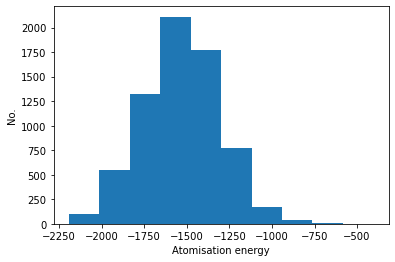

In [11]:
plt.hist(y_data)
plt.xlabel('Atomisation energy')
plt.ylabel("No.")

# Training on the topological features

In [12]:
%%time
output_metrics_tf=topol_regression_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter_Object_tf,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score', 
                   'mae_score', 
                   'rmse']
    )
output_metrics_tf

Metric selected is mae_score


KeyboardInterrupt: 

In [ ]:
%%time
output_metrics_pca=topol_regression_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca

Metric selected is mae_score
Step 15 validation: mae_score=0.846645
Step 30 validation: mae_score=0.859944
Step 45 validation: mae_score=0.854961
Step 60 validation: mae_score=0.844516
Step 75 validation: mae_score=0.880087
Step 90 validation: mae_score=0.809077
Step 105 validation: mae_score=0.912996
Step 120 validation: mae_score=0.786185
Step 135 validation: mae_score=0.929511
Step 150 validation: mae_score=0.894192
Step 165 validation: mae_score=0.896954
Step 180 validation: mae_score=0.887113
Step 195 validation: mae_score=0.848325
Step 210 validation: mae_score=0.854071
Step 225 validation: mae_score=0.81022
Step 240 validation: mae_score=0.795686
Step 255 validation: mae_score=0.831019
Step 270 validation: mae_score=0.801612
Step 285 validation: mae_score=0.803483
Step 300 validation: mae_score=0.819819
Step 315 validation: mae_score=0.810846
Step 330 validation: mae_score=0.77267
Step 345 validation: mae_score=0.76365
Step 360 validation: mae_score=0.816585
Step 375 validation:

Step 3105 validation: mae_score=0.805821
Step 3120 validation: mae_score=0.803141
Step 3135 validation: mae_score=0.761021
Step 3150 validation: mae_score=0.837325
Step 3165 validation: mae_score=0.821215
Step 3180 validation: mae_score=0.878043
Step 3195 validation: mae_score=0.779033
Step 3210 validation: mae_score=0.76197
Step 3225 validation: mae_score=0.760527
Step 3240 validation: mae_score=0.797631
Step 3255 validation: mae_score=0.806652
Step 3270 validation: mae_score=0.893615
Step 3285 validation: mae_score=0.847519
Step 3300 validation: mae_score=0.800328
Step 3315 validation: mae_score=0.775833
Step 3330 validation: mae_score=0.771477
Step 3345 validation: mae_score=0.944393
Step 3360 validation: mae_score=0.778844
Step 3375 validation: mae_score=0.822921
Step 3390 validation: mae_score=0.873438
Step 3405 validation: mae_score=0.859007
Step 3420 validation: mae_score=0.779612
Step 3435 validation: mae_score=0.782917
Step 3450 validation: mae_score=0.747277
Step 3465 validat

Step 6180 validation: mae_score=1.01377
Step 6195 validation: mae_score=0.80419
Step 6210 validation: mae_score=0.805198
Step 6225 validation: mae_score=0.795122
Step 6240 validation: mae_score=0.794982
Step 6255 validation: mae_score=0.938583
Step 6270 validation: mae_score=0.861247
Step 6285 validation: mae_score=0.796214
Step 6300 validation: mae_score=0.768486
Step 6315 validation: mae_score=0.779574
Step 6330 validation: mae_score=1.14263
Step 6345 validation: mae_score=0.991458
Step 6360 validation: mae_score=0.981853
Step 6375 validation: mae_score=0.968188
Step 6390 validation: mae_score=0.856597
Step 6405 validation: mae_score=0.849197
Step 6420 validation: mae_score=0.816003
Step 6435 validation: mae_score=1.10041
Step 6450 validation: mae_score=0.912898
Step 6465 validation: mae_score=0.946858
Step 6480 validation: mae_score=0.863945
Step 6495 validation: mae_score=0.856307
Step 6510 validation: mae_score=1.01884
Step 6525 validation: mae_score=0.845632
Step 6540 validation:

Step 9270 validation: mae_score=0.774082
Step 9285 validation: mae_score=0.762946
Step 9300 validation: mae_score=0.756916
Step 9315 validation: mae_score=0.754592
Step 9330 validation: mae_score=0.757103
Step 9345 validation: mae_score=0.759137
Step 9360 validation: mae_score=0.78664
Step 9375 validation: mae_score=0.812272
Step 9390 validation: mae_score=0.805314
Step 9405 validation: mae_score=0.807382
Step 9420 validation: mae_score=0.798734
Step 9435 validation: mae_score=0.799475
Step 9450 validation: mae_score=0.771375
Step 9465 validation: mae_score=0.760534
Step 9480 validation: mae_score=0.754732
Step 9495 validation: mae_score=0.755519
Step 9510 validation: mae_score=0.898281
Step 9525 validation: mae_score=0.857167
Step 9540 validation: mae_score=0.848082
Step 9555 validation: mae_score=0.814258
Step 9570 validation: mae_score=0.797982
Step 9585 validation: mae_score=0.802636
Step 9600 validation: mae_score=0.790221
Step 9615 validation: mae_score=0.801995
Step 9630 validat

Step 12225 validation: mae_score=0.820075
Step 12240 validation: mae_score=0.803985
Step 12255 validation: mae_score=0.785323
Step 12270 validation: mae_score=0.860121
Step 12285 validation: mae_score=0.777681
Step 12300 validation: mae_score=0.775807
Step 12315 validation: mae_score=0.775622
Step 12330 validation: mae_score=0.77577
Step 12345 validation: mae_score=0.905336
Step 12360 validation: mae_score=0.891595
Step 12375 validation: mae_score=0.848474
Step 12390 validation: mae_score=0.82425
Step 12405 validation: mae_score=0.812231
Step 12420 validation: mae_score=0.798871
Step 12435 validation: mae_score=0.768896
Step 12450 validation: mae_score=0.762186
Step 12465 validation: mae_score=0.75602
Step 12480 validation: mae_score=0.77557
Step 12495 validation: mae_score=0.802296
Step 12510 validation: mae_score=0.773196
Step 12525 validation: mae_score=0.790593
Step 12540 validation: mae_score=0.785257
Step 12555 validation: mae_score=0.78998
Step 12570 validation: mae_score=0.7923

...

Step 12075 validation: mae_score=0.854968
Step 12090 validation: mae_score=0.816504
Step 12105 validation: mae_score=0.812243
Step 12120 validation: mae_score=0.808937
Step 12135 validation: mae_score=0.809654
Step 12150 validation: mae_score=0.814907
Step 12165 validation: mae_score=0.847824
Step 12180 validation: mae_score=0.998456
Step 12195 validation: mae_score=0.937548
Step 12210 validation: mae_score=0.945709
Step 12225 validation: mae_score=0.964349
Step 12240 validation: mae_score=0.941298
Step 12255 validation: mae_score=0.943078
Step 12270 validation: mae_score=1.03032
Step 12285 validation: mae_score=0.887415
Step 12300 validation: mae_score=0.882262
Step 12315 validation: mae_score=0.849504
Step 12330 validation: mae_score=0.838685
Step 12345 validation: mae_score=0.832336
Step 12360 validation: mae_score=1.00282
Step 12375 validation: mae_score=0.936298
Step 12390 validation: mae_score=0.926228
Step 12405 validation: mae_score=0.925213
Step 12420 validation: mae_score=0.8

Step 15015 validation: mae_score=0.833294
Step 15030 validation: mae_score=0.807076
Step 15045 validation: mae_score=0.797172
Step 15060 validation: mae_score=0.792716
Step 15075 validation: mae_score=0.788827
Step 15090 validation: mae_score=0.788661
Step 15105 validation: mae_score=0.786102
Step 15120 validation: mae_score=0.802013
Step 15135 validation: mae_score=0.794837
Step 15150 validation: mae_score=0.775946
Step 15165 validation: mae_score=0.764636
Step 15180 validation: mae_score=0.765802
Step 15195 validation: mae_score=0.763334
Step 15210 validation: mae_score=0.766008
Step 15225 validation: mae_score=0.766018
Step 15240 validation: mae_score=0.774
Step 15255 validation: mae_score=0.775473
Step 15270 validation: mae_score=0.775355
Step 15285 validation: mae_score=0.772565
Step 15300 validation: mae_score=0.812476
Step 15315 validation: mae_score=0.801957
Step 15330 validation: mae_score=0.788776
Step 15345 validation: mae_score=0.781923
Step 15360 validation: mae_score=0.77

Step 17985 validation: mae_score=0.877505
Step 18000 validation: mae_score=0.871999
Step 18015 validation: mae_score=0.89678
Step 18030 validation: mae_score=0.894842
Step 18045 validation: mae_score=0.877108
Step 18060 validation: mae_score=0.822864
Step 18075 validation: mae_score=0.77575
Step 18090 validation: mae_score=0.780785
Step 18105 validation: mae_score=0.774532
Step 18120 validation: mae_score=0.771472
Step 18135 validation: mae_score=0.771775
Step 18150 validation: mae_score=0.844479
Step 18165 validation: mae_score=0.968796
Step 18180 validation: mae_score=0.904973
Step 18195 validation: mae_score=0.862392
Step 18210 validation: mae_score=0.861233
Step 18225 validation: mae_score=0.854134
Step 18240 validation: mae_score=0.853642
Step 18255 validation: mae_score=0.922117
Step 18270 validation: mae_score=0.933001
Step 18285 validation: mae_score=0.930411
Step 18300 validation: mae_score=0.925121
Step 18315 validation: mae_score=0.912067
Step 18330 validation: mae_score=0.9

Step 20925 validation: mae_score=0.804094
Step 20940 validation: mae_score=0.878801
Step 20955 validation: mae_score=0.93349
Step 20970 validation: mae_score=0.840406
Step 20985 validation: mae_score=0.793372
Step 21000 validation: mae_score=0.791345
Step 21015 validation: mae_score=0.785336
Step 21030 validation: mae_score=0.781416
Step 21045 validation: mae_score=0.781562
Step 21060 validation: mae_score=0.794898
Step 21075 validation: mae_score=0.782901
Step 21090 validation: mae_score=0.766786
Step 21105 validation: mae_score=0.766925
Step 21120 validation: mae_score=0.769597
Step 21135 validation: mae_score=0.768212
Step 21150 validation: mae_score=0.772924
Step 21165 validation: mae_score=0.857754
Step 21180 validation: mae_score=0.87085
Step 21195 validation: mae_score=0.861979
Step 21210 validation: mae_score=0.807395
Step 21225 validation: mae_score=0.832447
Step 21240 validation: mae_score=0.839173
Step 21255 validation: mae_score=0.828126
Step 21270 validation: mae_score=0.7

Step 23880 validation: mae_score=0.793875
Step 23895 validation: mae_score=0.770834
Step 23910 validation: mae_score=0.778424
Step 23925 validation: mae_score=0.787063
Step 23940 validation: mae_score=0.79045
Step 23955 validation: mae_score=0.935124
Step 23970 validation: mae_score=0.952854
Step 23985 validation: mae_score=0.952618
Step 24000 validation: mae_score=0.946286
Step 24015 validation: mae_score=0.928637
Step 24030 validation: mae_score=0.914955
Step 24045 validation: mae_score=0.909052
Step 24060 validation: mae_score=0.882293
Step 24075 validation: mae_score=0.862212
Step 24090 validation: mae_score=0.858309
Step 24105 validation: mae_score=0.91958
Step 24120 validation: mae_score=0.928253
Step 24135 validation: mae_score=0.918816
Step 24150 validation: mae_score=0.935935
Step 24165 validation: mae_score=1.06254
Step 24180 validation: mae_score=1.10984
Step 24195 validation: mae_score=1.06137
Step 24210 validation: mae_score=1.0214
Step 24225 validation: mae_score=0.998362

In [ ]:
%%time
output_metrics_pca_no_transform=no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

## Dataset loaders for the other inputs if you want to play around with them

In [ ]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
len(train_dataset_ECFP) + len(valid_dataset_ECFP) + len(test_dataset_ECFP)

In [ ]:
featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
tasks, datasets, transformers_CM_eig = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_CM_eig, splitter="stratified")
train_dataset_CM_eig, valid_dataset_CM_eig, test_dataset_CM_eig = datasets
len(train_dataset_CM_eig) + len(valid_dataset_CM_eig) + len(test_dataset_CM_eig)

In [ ]:
featurizer_weave = dc.feat.WeaveFeaturizer()
tasks, datasets, transformers_weave = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_weave, splitter="stratified")
train_dataset_weave, valid_dataset_weave, test_dataset_weave = datasets
len(train_dataset_weave) + len(valid_dataset_weave) + len(test_dataset_weave)

In [ ]:
#featurizer_rdkit = dc.feat.RDKitDescriptors()
#tasks, datasets, transformers_rdkit = dc.molnet.load_qm7(
#    shard_size=2000, featurizer=featurizer_rdkit, splitter="stratified")
#train_dataset_rdkit, valid_dataset_rdkit, test_dataset_rdkit = datasets
#len(train_dataset_rdkit) + len(valid_dataset_rdkit) + len(test_dataset_rdkit)

## Controls

In [ ]:
#featurizer = dc.feat.OneHotFeaturizer()#

#tasks, datasets, transformers = dc.molnet.load_qm7(
#            shard_size=2000, featurizer=featurizer, splitter="stratified")
        


## need to install stuff to do these
#featurizer = dc.feat.PubChemFingerprint()

#featurizer = dc.feat.Mol2VecFingerprint()

#featurizer = dc.feat.OneHotFeaturizer()

In [ ]:
def dataset_selector(setting):
    """makes data inside experiment function
    """
    print('!!!!Make this function new for each new dataset!!!!')
    if setting == 'ECFP':
        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer="ECFP", splitter="stratified")
    elif setting == 'CM_eig':
        featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer=featurizer_CM_eig, splitter="stratified")
    elif setting == 'rdkit':
        featurizer_rdkit = dc.feat.RDKitDescriptors()
        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer=featurizer_rdkit, splitter="stratified")
        
    elif setting == 'MACCS':
        featurizer = dc.feat.MACCSKeysFingerprint()

        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer=featurizer, splitter="stratified")
    elif setting == '1HOT':
        featurizer = dc.feat.OneHotFeaturizer()

        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer=featurizer, splitter="stratified")
    elif setting == 'CM':
        featurizer = dc.feat.CoulombMatrix(max_atoms=23)
        tasks, datasets, transformers = dc.molnet.load_qm7(
            shard_size=2000, featurizer=featurizer, splitter="stratified")

    else:
        print('meh no data imported')
    return tasks, datasets, transformers

dataset_selector('CM')
#featurizer = dc.feat.CoulombMatrix(max_atoms=23)
#tasks, datasets, transformers = dc.molnet.load_qm7(
#    shard_size=2000, featurizer=featurizer, splitter="stratified")
#train_dataset, valid_dataset, test_dataset = datasets

#model=dc.models.DTNNModel(n_tasks = len(tasks), nb_epochs=3)
#model.fit(train_dataset, nb_epoch=3)

## ECFP

In [ ]:

def deepchem_regression_experiment(
    metrics,
    metric_selector,
    setting='ECFP',
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        ################### this bit is different ##############
        print(f'Using dataset selector setting {setting}')
        tasks, datasets, transformers=dataset_selector(setting)
        train_dataset, valid_dataset, test_dataset = datasets
        task_list = tasks
        ########################################################
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse', 'tr_r2', 'tr_mae','tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse','te_r2', 'te_mae', 'te_rmse'])
    return pd_out




In [ ]:

def deepchem_CM_regression_experiment(
    metrics,
    metric_selector,
    setting='ECFP',
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        ################### this bit is different ##############
        print(f'Using dataset selector setting {setting}')
        tasks, datasets, transformers=dataset_selector(setting)
        train_dataset, valid_dataset, test_dataset = datasets
        task_list = tasks
        ########################################################
        # actual model here
        model=dc.models.DTNNModel(n_tasks = len(tasks), nb_epochs=3)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse', 'tr_r2', 'tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse','te_r2', 'te_mae',  'te_rmse'])
    return pd_out




In [ ]:
%%time
output_metrics_cm=deepchem_CM_regression_experiment(
    metrics,
    metric_selector=2,
    setting='CM',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_cm.head(3)

# Control experiments:
regression first

In [ ]:
%%time
output_metrics_ecfp = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='ECFP',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_ecfp

### Coulomb matrix eigenvalues

In [ ]:
%%time
output_metrics_cm_eig = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='CM_eig',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_cm_eig

### rdkit features

In [ ]:
%%time
output_metrics_rdkit = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='rdkit',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_rdkit

## MACCS features

In [ ]:
%%time
output_metrics_maccs = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='MACCS',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_maccs

In [ ]:
#Best=1.92

data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm['tr_mae'],
     output_metrics_cm['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca_no_transform['tr_mae'],
     output_metrics_pca_no_transform['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,14.5],[153, 153],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5,9.5,11.5,13.5],['ECFP',"MACCS","rdkit","CM","CM_eig","TDAF","PCA-TDAF"])
plt.ylabel('MAE kcal/mol')
#plt.savefig("dc_NN_MR_rmse.png")

In [ ]:
list_of_data_frames=[output_metrics_ecfp,
     output_metrics_maccs,
     output_metrics_rdkit,
     output_metrics_cm,
     output_metrics_cm_eig,
     output_metrics_tf,
     output_metrics_pca_no_transform]

list_of_data_frames_names=["output_metrics_ecfp",
     "output_metrics_maccs",
     "output_metrics_rdkit",
     "output_metrics_cm",
     "output_metrics_cm_eig",
     "output_metrics_tf",
     "output_metrics_pca_no_transform"]

In [ ]:
list_of_data_frames_names[4] + '.csv'

In [ ]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


# stuff that doesn't work yet

# graph convolution

In [ ]:
import numpy
numpy.version.version

In [ ]:
featurizer = dc.feat.ConvMolFeaturizer()
tasks, datasets, transformers_gc = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer, splitter="stratified")
train_dataset, valid_dataset, test_dataset = datasets
n_tasks = len(tasks)
model = dc.models.GraphConvModel(n_tasks, mode='regression')
model.fit(train_dataset, nb_epoch=50)

In [ ]:
output_metrics_1hot = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='1HOT',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_1hot

In [ ]:
model = dc.models.GraphConvModel(n_tasks = len(tasks),mode='regression')
model.fit( train_dataset, nb_epoch=3)

In [ ]:
n_tasks = len(tasks)
model = dc.models.GraphConvModel(n_tasks, mode='regression')
model.fit(train_dataset, nb_epoch=50)

In [ ]:
featurizer = dc.feat.CoulombMatrix(max_atoms=23)
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer, splitter="stratified")
train_dataset, valid_dataset, test_dataset = datasets

model=dc.models.DTNNModel(n_tasks = len(tasks), nb_epochs=3)
model.fit(train_dataset, nb_epoch=3)

In [ ]:
featurizer_weave = dc.feat.WeaveFeaturizer()
tasks, datasets, transformers_weave = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_weave, splitter="stratified")
train_dataset_weave, valid_dataset_weave, test_dataset_weave = datasets
len(train_dataset_weave) + len(valid_dataset_weave) + len(test_dataset_weave)

In [ ]:
featurizer = dc.feat.MACCSKeysFingerprint()

featurizer = dc.feat.CircularFingerprint(size=2048, radius=4)

featurizer = dc.feat.PubChemFingerprint()

featurizer = dc.feat.Mol2VecFingerprint()

featurizer = dc.feat.OneHotFeaturizer()

In [ ]:
import deepchem as dc
featurizers = dc.feat.CoulombMatrix(max_atoms=23)
input_file = 'deepchem/feat/tests/data/water.sdf' # really backed by water.sdf.csv
tasks = ["atomization_energy"]
loader = dc.data.SDFLoader(tasks, featurizer=featurizers)
dataset = loader.create_dataset(input_file)

In [ ]:
featurizer = dc.feat.BPSymmetryFunctionInput(max_atoms=10)

In [ ]:
smiles = ['CC(=O)OC1=CC=CC=C1C(=O)O']
featurizer = dc.feat.SmilesToImage(img_size=80, img_spec='std')
images = featurizer.featurize(smiles)
type (images[0])

images[0].shape # (img_size, img_size, 1)

In [ ]:
!pip install transformers
from deepchem.feat.smiles_tokenizer import SmilesTokenizer
current_dir = os.path.dirname(os.path.realpath(__file__))
vocab_path = os.path.join(current_dir, 'tests/data', 'vocab.txt')
tokenizer = SmilesTokenizer(vocab_path)
print(tokenizer.encode("CC(=O)OC1=CC=CC=C1C(=O)O"))

In [ ]:
smiles = ["C", "CCC"]
featurizer=dc.feat.ConvMolFeaturizer(per_atom_fragmentation=False)
f = featurizer.featurize(smiles)
# Using ConvMolFeaturizer to create featurized fragments derived from molecules of interest.
# This is used only in the context of performing interpretation of models using atomic
# contributions (atom-based model interpretation)
smiles = ["C", "CCC"]
featurizer=dc.feat.ConvMolFeaturizer(per_atom_fragmentation=True)
f = featurizer.featurize(smiles)
len(f)

In [ ]:
featurizer = dc.feat.OneHotFeaturizer()
smiles = ['CCC']
encodings = featurizer.featurize(smiles)
type(encodings[0])

encodings[0].shape
(100, 35)
featurizer.untransform(encodings[0])
'CCC'

In [ ]:
encodings

## Weave

In [ ]:
test_dataset_weave

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_weave, validate_scores_weave, test_scores_weave = [],[],[]
for i in range(10):
    model = dc.models.DTNNModel(
        n_tasks=len(tasks))
    callback = dc.models.ValidationCallback(valid_dataset_weave, 5, metric1)
    model.fit(train_dataset_weave, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    #train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                           #            metric1)['mae_score'])
    #validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                            #              metric1)['mae_score'])
    #test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                             #         metric1)['mae_score'])
    
        # line below returns a dictionary
    train_scores_weave.append(
        model.evaluate(
            train_dataset_weave, 
            metric1,
            transformers = transformers_weave)['mae_score'])
    validate_scores_weave.append(
        model.evaluate(
            valid_dataset_weave, 
            metric1,transformers = transformers_weave)['mae_score']
            )
    test_scores_weave.append(
        model.evaluate(
            test_dataset_weave, 
            metric1,transformers = transformers_weave)['mae_score']
            )

In [ ]:
import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_tf, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
scipy.stats.ttest_ind(test_scores_rdkit, test_scores_tf, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
scipy.stats.ttest_ind(test_scores_rdkit, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
means

In [ ]:
output_metrics_tf['tr_mae']

In [ ]:
tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets
n_tasks = len(tasks)
model = dc.models.GraphConvModel(n_tasks, mode='classification')
model.fit(train_dataset, nb_epoch=50)

## plots the graph

In [ ]:
#Best=1.92

data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_cm['tr_mae'],
     output_metrics_cm['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca_no_transform['tr_mae'],
     output_metrics_pca_no_transform['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,15.5],[153, 153],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5,9.5,11.5,13.5],['ECFP',"rdkit","MACCS","CM","CM_eig","TDAF","PCA-TDAF"])
plt.ylabel('MAE kcal/mol')
#plt.savefig("dc_NN_MR_rmse.png")

## Controls

In [ ]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
    params_dict, 
    train_dataset_ECFP, 
    valid_dataset_ECFP, 
    metric, 
    transformers)

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ECFP, validate_scores_ECFP, test_scores_ECFP = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_ECFP.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ECFP.append(model.evaluate(valid_dataset_ECFP,
                                          metric1)['mae_score'])
    test_scores_ECFP.append(model.evaluate(test_dataset_ECFP,
                                      metric1)['mae_score'])

In [ ]:
test_scores_ECFP

In [ ]:

transformers[1].untransform(test_scores_ECFP[0])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
# the splitter does not shuffle the data
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")
sdf_train_dataset, sdf_valid_dataset, sdf_test_dataset = datasets

In [ ]:

sdf_data_dir=r'F:\Nextcloud\science\Datasets'


In [ ]:
tasks = ["atomization_energy"]
sdf_filename='gdb7.sdf'
#dataset_file = "../../datasets/gdb1k.sdf"
smiles_field = "smiles"
mol_field = "mol"

In [ ]:
featurizer_CM = dc.feat.CoulombMatrixEig(23, remove_hydrogens=False)
loader = dc.data.SDFLoader(
      tasks=["u0_atom"],
      featurizer=featurizer_CM)
dataset = loader.create_dataset(os.path.join(sdf_data_dir, sdf_filename))

In [ ]:

random_splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = random_splitter.train_valid_test_split(dataset)

In [ ]:
transformers = [
    dc.trans.NormalizationTransformer(transform_X=True, dataset=train_dataset),
    dc.trans.NormalizationTransformer(transform_y=True, dataset=train_dataset)]

for dataset in [train_dataset, valid_dataset, test_dataset]:
  for transformer in transformers:
      dataset = transformer.transform(dataset)

In [ ]:
def rf_model_builder(model_dir, **model_params):
  sklearn_model = RandomForestRegressor(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)
params_dict = {
    "n_estimators": [10, 100],
    "max_features": ["auto", "sqrt", "log2", None],
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(rf_model_builder)
best_rf, best_rf_hyperparams, all_rf_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_rf_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_rf_hyperparams)

In [ ]:

def krr_model_builder(model_dir, **model_params):
  sklearn_model = KernelRidge(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)

params_dict = {
    "kernel": ["laplacian"],
    "alpha": [0.0001],
    "gamma": [0.0001]
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(krr_model_builder)
best_krr, best_krr_hyperparams, all_krr_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_krr_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_krr_hyperparams)

In [ ]:
best_krr.model.score(test_dataset.X, test_dataset.y)

In [ ]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
fh.close()